# JPM Quantitative Research

### Project Overview

This notebook simulates a real-world quantitative research workflow used to support energy trading decisions, based on a virtual project from J.P. Morgan’s Quantitative Research program.

The objective of this project is to analyze historical and forecasted natural gas prices to enable pricing of physical storage contracts. These contracts are used by traders and supply chain participants to take advantage of seasonal price spreads.

The analysis proceeds in two main stages:

1. **Price Modeling**
   - Load and visualize historical monthly gas prices
   - Fit a Holt-Winters time series model to capture seasonal patterns
   - Forecast future prices for the next 12 months
   - Use interpolation to estimate gas prices on arbitrary dates

2. **Storage Contract Valuation**
   - Define a contract valuation function based on injection/withdrawal schedules, fees, and storage constraints
   - Combine the estimated prices with operational parameters to compute gross and net contract value
   - Evaluate profitability of specific trade scenarios

This end-to-end workflow integrates data processing, forecasting, and financial modeling to support decision-making in the natural gas market.


### Task 1: Investigate and analyze price data
#### 1.1 Load and Prepare the Natural Gas Price Data
We begin by importing the necessary libraries and reading in the monthly natural gas price data from a CSV file. The dataset includes historical prices, each recorded at the end of a calendar month.

- The Dates column is converted to datetime format using pd.to_datetime().
 
- We then set the Dates column as the index to facilitate time series analysis.

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np



price_df = pd.read_csv('Nat_Gas.csv')
price_df['Dates'] = pd.to_datetime(price_df['Dates'])

# Step 2: 把日期设为索引
price_df.set_index('Dates', inplace=True)

print(price_df.head())
print(price_df.shape)

            Prices
Dates             
2020-10-31    10.1
2020-11-30    10.3
2020-12-31    11.0
2021-01-31    10.9
2021-02-28    10.9
(48, 1)


C:\Users\26759\AppData\Local\Temp\ipykernel_7744\1509055577.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  price_df['Dates'] = pd.to_datetime(price_df['Dates'])


This gives us a DataFrame indexed by time, where each row represents the natural gas price at month-end. The dataset has shape `(n, 1)`, where `n` is the number of months observed.

#### 1.2 Visualize Monthly Natural Gas Prices
We plot the natural gas price time series to examine its historical behavior over time. The line chart below shows price fluctuations from late 2020 through mid-2024.

- The x-axis represents the timeline (monthly frequency).
 
- The y-axis shows the market price of natural gas (in USD).

- A grid is added to improve readability.

This visualization reveals:

- Seasonal fluctuations in price levels

- An overall upward trend with periodic dips, suggesting potential seasonality or external market influences


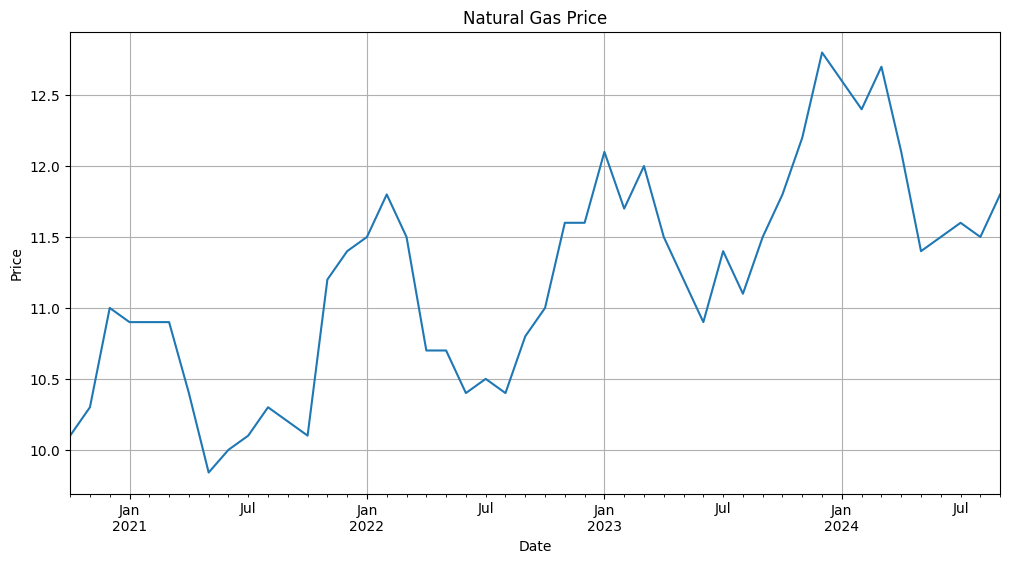

In [23]:
# Plotting the data
price_df['Prices'].plot(title = 'Natural Gas Price', figsize = (12, 6))
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

#### 1.3 Fit a Holt-Winters Exponential Smoothing Model
To capture both trend and seasonality in the gas price time series, we apply the Holt-Winters exponential smoothing model using an additive trend and additive seasonality with a 12-month seasonal period.

- `trend='add'`: Assumes price changes accumulate linearly over time.
 
- `seasonal='add'`: Captures repeating seasonal fluctuations.

- `seasonal_periods=12`: Reflects monthly seasonality over a 1-year cycle.

After fitting the model to the historical data, we plot both:

- The actual monthly prices (`Prices`)

- The fitted values from the Holt-Winters model (`Fitted`)

This visualization allows us to assess the model’s goodness of fit.

c:\Users\26759\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


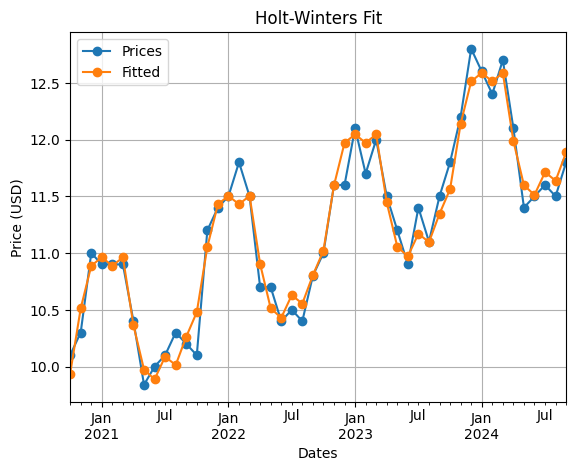

In [2]:
# Build a Holt-Winters model
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 使用 Holt-Winters 乘性模型（适合价格涨跌幅会放大的情况）
hw_model = ExponentialSmoothing(price_df['Prices'], trend='add', seasonal='add', seasonal_periods=12)
hw_fit = hw_model.fit()

# 加入预测值
price_df['Fitted'] = hw_fit.fittedvalues

# 画图对比真实值与模型拟合值
price_df[['Prices', 'Fitted']].plot(marker='o', title='Holt-Winters Fit')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()


#### 1.4 Forecast Natural Gas Prices for the Next 12 Months
With the Holt-Winters model fitted to historical data, we now forecast the natural gas prices for the next 12 months.

We first generate a future datetime index that begins from the end of the current data (`MonthEnd` frequency).

We then use the `.forecast(12)` method from the fitted model to predict prices one year into the future.

The predicted prices are stored in a new DataFrame (`forecast_df`) and appended to the original data.

The result, `full_df`, contains a continuous time series of both historical and forecasted prices, ready for downstream analysis or visualization.

This extended dataset will be essential for valuing future storage contracts and modeling hypothetical trades.

In [3]:
# 生成未来 12 个月日期
price_df.index = pd.to_datetime(price_df.index)
last_date = price_df.index[-1]  # 假设你已经设了 datetime index
future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(), periods=12, freq='M')

# 预测未来 12 个月
forecast = hw_fit.forecast(12)
forecast_df = pd.DataFrame({'Prices': forecast.values}, index=future_dates)

# 合并历史和未来价格
full_df = pd.concat([price_df[['Prices']], forecast_df])
full_df = full_df.sort_index()  # 确保按时间排序


C:\Users\26759\AppData\Local\Temp\ipykernel_7744\2751059099.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(), periods=12, freq='M')


In [27]:
print(full_df.head())

            Prices
2020-10-31    10.1
2020-11-30    10.3
2020-12-31    11.0
2021-01-31    10.9
2021-02-28    10.9


#### 1.5 Build a Smooth Interpolation & Forecasting Function
To estimate the natural gas price on any date, we combine interpolation for historical dates and forecasting for future dates.

##### Part 1: Interpolation Using PCHIP
We use the PCHIP (Piecewise Cubic Hermite Interpolating Polynomial) interpolator from `scipy.interpolate` to smoothly interpolate prices between monthly data points.

The index is converted to integer timestamps for compatibility.

This method preserves monotonicity and avoids overshooting, making it suitable for pricing curves.

In [4]:
# 构造一个平滑插值器
from scipy.interpolate import PchipInterpolator
import numpy as np

# 转换为整数时间戳（避免 datetime 格式问题）
x = full_df.index.astype(np.int64)
y = full_df['Prices'].values

# 构造平滑插值器
spline = PchipInterpolator(x, y)


##### Part 2: Define estimate_price() Function
The `estimate_price()` function handles:

- Historical dates → interpolated price via spline

- Future dates within 12-month forecast range → Holt-Winters forecast

- Dates beyond available data → last known forecast (optional fallback or error)

In [5]:
# 构造一个预测函数
def estimate_price(date_str):
    date = pd.to_datetime(date_str)
    ts = date.value
    
    if date < full_df.index[0]:
        raise ValueError("Date is before available data.")
    
    elif ts <= x[-1]:
        return float(spline(ts))  # 插值
    
    else:
        # 额外外推超过预测期（可选，当前最多支持未来 12 月）
        months_ahead = (date.year - full_df.index[-1].year) * 12 + (date.month - full_df.index[-1].month)
        if months_ahead <= 0:
            return float(forecast[date.strftime('%Y-%m-%d')])  # 可能还在 forecast 里
        else:
            future_value = hw_fit.forecast(months_ahead).iloc[-1]
            return float(future_value)


##### Part 3: Plot Estimated Daily Prices
We generate a daily time index and apply `estimate_price()` to every date from the beginning of the dataset to the forecast horizon. The resulting plot includes:

- A smooth daily curve of prices (blue line)

- Original historical prices (blue points)

- Future forecast points (green points)

This provides a comprehensive view of natural gas price dynamics over time, suitable for contract valuation and scenario analysis.

11.113822966667787
13.072169977631734


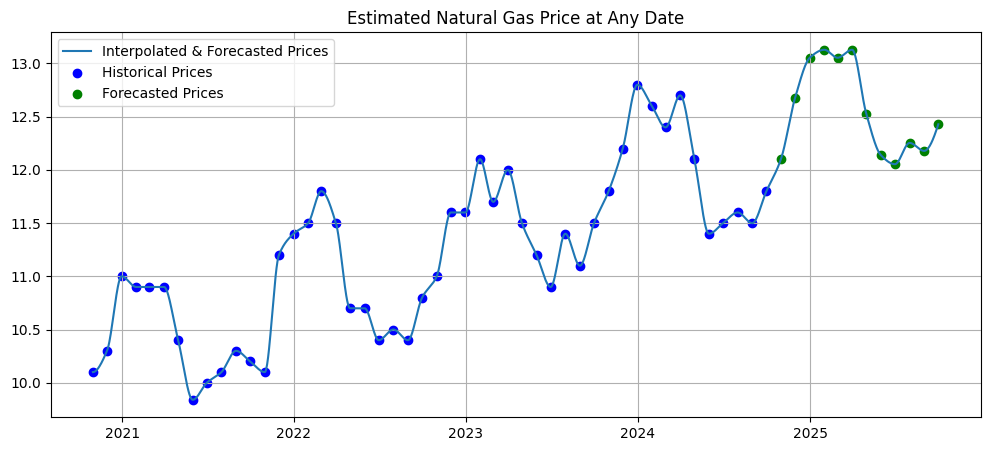

In [6]:
# 画出预测结果
print(estimate_price('2023-07-14'))  # 历史插值
print(estimate_price('2025-03-10'))  # 未来预测

# 画图展示价格曲线
import matplotlib.pyplot as plt

daily_index = pd.date_range(start=full_df.index[0], end=full_df.index[-1], freq='D')
daily_prices = [estimate_price(str(d.date())) for d in daily_index]

plt.figure(figsize=(12, 5))
plt.plot(daily_index, daily_prices, label='Interpolated & Forecasted Prices')
plt.scatter(price_df.index, price_df['Prices'], color='blue', label='Historical Prices')
plt.scatter(forecast_df.index, forecast_df['Prices'], color='green', label='Forecasted Prices')
plt.title('Estimated Natural Gas Price at Any Date')
plt.legend()
plt.grid(True)

plt.show()



**Visual Output**: Daily Price Curve with Interpolation & Forecast
The figure above illustrates the estimated natural gas price for any given date, combining both historical interpolation and future forecasting.

🔵 **Blue dots**: Actual historical monthly price data

🟢 **Green dots**: Monthly forecasted prices using Holt-Winters

🔷 **Blue line**: Interpolated and extrapolated daily price curve from October 2020 to September 2025

This smoothed, high-frequency price series enables granular pricing for gas storage contracts, regardless of injection or withdrawal date. It serves as the pricing backbone for the next steps, where we evaluate contract value based on specific trade dates and cash flows.

#### 1.6 Estimate Price for a Specific Date
To support flexible pricing of storage contracts, we use the `estimate_price()` function to compute the natural gas price on any arbitrary date, even if it's not a month-end.

For example, the estimated price on July 14, 2023 is:

In [40]:
# Compute the price for a specific date
estimate_price('2023-07-14')  # 返回该日的天然气估值


11.113822966667787

This capability is especially useful for valuing contracts with custom injection or withdrawal dates that do not align with the monthly snapshots in the dataset.

### Task 2: Storage Contract Valuation
To support contract pricing under various trade scenarios, we define a flexible function that calculates the net economic value of a natural gas storage agreement.


#### 2.1 Define `price_contract()` Function
This function models the value of a storage deal based on custom injection and withdrawal schedules. It takes into account:

- Cash flows from buying and selling gas
- Per-unit operational fees for injection and withdrawal
- Fixed monthly storage costs
- Maximum capacity constraints

The function computes:

- Total injection cost (based on estimated prices at each injection date)
- Total withdrawal revenue (same logic, for sale dates)
- Fees for operations
- Storage cost across the total duration
- Net value of the contract:
\begin{align*}
\text{Net Value} = \text{Revenue} - \text{Cost} - \text{Fees}
\end{align*}
This modular function enables dynamic evaluation of any proposed trade schedule.

In [ ]:
def price_contract(
    injection_dates,         # list of str
    withdrawal_dates,        # list of str
    volume_per_injection,    # float
    volume_per_withdrawal,   # float
    max_storage_volume,      # float
    storage_cost_per_month,  # float
    inj_withdraw_fee_per_unit,  # float
    estimate_price_func       # callable(date_str) → price
):
    import pandas as pd
    assert sum([volume_per_injection]*len(injection_dates)) <= max_storage_volume, "Storage over capacity"
    assert sum([volume_per_withdrawal]*len(withdrawal_dates)) <= max_storage_volume, "Withdraws exceed capacity"

    # Cash flows
    total_injection_cost = 0
    for date in injection_dates:
        price = estimate_price_func(date)
        total_injection_cost += price * volume_per_injection

    total_withdrawal_revenue = 0
    for date in withdrawal_dates:
        price = estimate_price_func(date)
        total_withdrawal_revenue += price * volume_per_withdrawal

    # Injection/withdrawal fee
    total_inj_with_fee = inj_withdraw_fee_per_unit * (volume_per_injection * len(injection_dates)
                                                      + volume_per_withdrawal * len(withdrawal_dates))

    # Storage duration = from first injection to last withdrawal
    all_dates = pd.to_datetime(injection_dates + withdrawal_dates)
    storage_months = (all_dates.max().to_period('M') - all_dates.min().to_period('M')).n + 1
    total_storage_cost = storage_cost_per_month * storage_months

    # Contract value
    gross = total_withdrawal_revenue - total_injection_cost
    total_costs = total_inj_with_fee + total_storage_cost
    net_value = gross - total_costs

    return {
        'Total Injection Cost': round(total_injection_cost, 2),
        'Total Withdrawal Revenue': round(total_withdrawal_revenue, 2),
        'Injection/Withdrawal Fees': round(total_inj_with_fee, 2),
        'Storage Cost': round(total_storage_cost, 2),
        'Gross Spread': round(gross, 2),
        'Net Contract Value': round(net_value, 2)
    }


### 2.2 Run a Sample Storage Contract

This particular contract appears to yield a net loss of $\$97,328.67$, primarily due to storage fees outweighing the trading margin. Adjusting timing or fee structure may be needed to achieve profitability.

In [8]:
result = price_contract(
    injection_dates = ['2024-04-15', '2024-05-15'],
    withdrawal_dates = ['2024-12-15', '2025-01-15'],
    volume_per_injection = 0.5e6,   # 50 万 MMBtu 每次注入
    volume_per_withdrawal = 0.5e6,  # 同样提取
    max_storage_volume = 1e6,
    storage_cost_per_month = 100000,
    inj_withdraw_fee_per_unit = 0.01,
    estimate_price_func = estimate_price  # 你已有的预测函数
)

print(result)


{'Total Injection Cost': 12080858.3, 'Total Withdrawal Revenue': 13003529.63, 'Injection/Withdrawal Fees': 20000.0, 'Storage Cost': 1000000, 'Gross Spread': 922671.33, 'Net Contract Value': -97328.67}


### Conclusion

This notebook demonstrates a full-cycle prototype for valuing natural gas storage contracts based on historical and projected market prices.

Key takeaways:

- The Holt-Winters model effectively captured both seasonal and trend components in gas prices, enabling forward-looking pricing over a one-year horizon.
- Interpolation methods were used to estimate prices at arbitrary injection or withdrawal dates with daily granularity.
- A flexible valuation function was developed to calculate the net value of storage deals, accounting for price spreads, storage costs, and operational fees.

This modeling framework can be extended to support strategy simulation, contract optimization, or integration with risk and pricing systems. It also illustrates how quantitative research methods directly support trading decisions in energy markets.

